Part 1 & 2: ইমপোর্ট এবং ডেটা পাথ (Colab ড্রাইভ বাদ দিয়ে)

In [2]:
!pip install torch torchvision torchaudio

In [3]:
!pip install optuna scikit-learn matplotlib pandas numpy pillow torch torchvision torchaudio
import os
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

In [4]:
# --- ১. প্রয়োজনীয় লাইব্রেরি সেটআপ (Colab Drive বাদ দেওয়া হয়েছে) ---
import os
import json
import copy
import gc  # মেমোরি ম্যানেজমেন্টের জন্য
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import accuracy_score, f1_score

import optuna 
import matplotlib.pyplot as plt
import optuna.visualization.matplotlib as vis_mpl

# --- ২. ডেটাসেট পাথ (আপনার ম্যাকের সঠিক পাথগুলো এখানে বসান) ---
# উদাহরণ: CSV_PATH = '/Users/joyassroy/Desktop/EYE_IMAGE/Annotations.csv'
CSV_PATH = '/Users/joyassroy/Downloads/Annotations.csv'
IMG_DIR = '/Users/joyassroy/Downloads/Original_Slit-lamp_Images'

df = pd.read_csv(CSV_PATH)
image_to_labels = {}

for idx, row in df.iterrows():
    filename = str(row['filename']).strip()
    if filename not in image_to_labels:
        image_to_labels[filename] = []

    attr_str = row['attributes']
    try:
        data = json.loads(attr_str)
        lesion = data.get('lesion', '').strip()
        if lesion != "":
            image_to_labels[filename].append(lesion)
    except:
        pass

final_data = []
for filename, labels in image_to_labels.items():
    labels = list(set(labels)) 
    if len(labels) == 0:
        labels = ['Normal']
    final_data.append({'filename': filename, 'labels': labels})

df_final = pd.DataFrame(final_data)

mlb = MultiLabelBinarizer()
labels_encoded = mlb.fit_transform(df_final['labels'])
classes = mlb.classes_
print(f"Total Unique Classes ({len(classes)}): {list(classes)}")

X = df_final['filename'].values
y = labels_encoded

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

class MultiLabelKeratitisDataset(Dataset):
    def __init__(self, image_names, labels, img_dir, transform=None):
        self.image_names = image_names
        self.labels = labels
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        label = torch.FloatTensor(self.labels[idx])
        return image, label

Total Unique Classes (15): ['Cataract', 'Conjunctival cyst', 'Conjunctival injection', 'Corneal / Conjunctival tumor', 'Corneal dystrophy', 'Corneal scarring', 'Intraocular lens', 'Keratitis', 'Lens dislocation', 'Lens dislocation/Cataract', 'Normal', 'Pigmented nevus', 'Pinguecula', 'Pterygium', 'Subconjunctival hemorrhage']


Part 3: ডিভাইস সিলেক্ট করা (M1 Mac-এর জন্য MPS)

In [6]:
# --- ৩. ডেটা অগমেন্টেশন এবং ডিভাইস সেটআপ ---
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# M1 Mac এর জন্য MPS (Metal Performance Shaders) সেট করা
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Training on Device: {device}")

def build_model(num_classes):
    model = models.efficientnet_v2_m(weights=models.EfficientNet_V2_M_Weights.DEFAULT)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, num_classes)
    return model.to(device)

Training on Device: mps


Part 4: Optuna Objective Function (RAM ম্যানেজমেন্ট ও num_workers=0 সহ)

In [8]:
# --- ৪. Optuna Objective Function ---
def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True) 
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW", "RMSprop"]) 
    batch_size = trial.suggest_categorical("batch_size", [4,8]) 

    train_dataset = MultiLabelKeratitisDataset(X_train, y_train, IMG_DIR, transform=train_transforms)
    val_dataset = MultiLabelKeratitisDataset(X_val, y_val, IMG_DIR, transform=val_test_transforms)

    # num_workers=0 করা হয়েছে
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    model = build_model(len(classes))
    criterion = nn.BCEWithLogitsLoss()

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "AdamW":
        optimizer = optim.AdamW(model.parameters(), lr=lr)
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=lr)

    EPOCHS = 5
    best_val_loss = float('inf')

    for epoch in range(EPOCHS):
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)

        val_loss = val_loss / len(val_dataset)
        
        # --- Memory Clearing ---
        del inputs, labels, outputs, loss
        gc.collect()
        if torch.backends.mps.is_available():
            torch.mps.empty_cache()

        trial.report(val_loss, epoch)

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    # মেমোরি ক্লিয়ার
    del model
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache() 

    return val_loss

Part 5: Optuna রান এবং লোকাল ড্রাইভে গ্রাফ সেভ

In [10]:
# --- ৫. Optuna Study তৈরি এবং রান করা ---
print("Bayesian Optimization শুরু হচ্ছে...")

study = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=10) 

print("\nBest Trial Details:")
best_trial = study.best_trial
print(f"  Value (Val Loss): {best_trial.value}")
print("  Best Hyperparameters: ")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

print("\nOptuna গ্রাফ তৈরি করা হচ্ছে...")

# কারেন্ট ফোল্ডারেই গ্রাফ সেভ হবে
vis_mpl.plot_optimization_history(study)
plt.title("Optimization History Plot")
plt.tight_layout()
plt.savefig('./Optuna_History.png', dpi=300, bbox_inches='tight')
plt.close()

vis_mpl.plot_param_importances(study)
plt.title("Hyperparameter Importances")
plt.tight_layout()
plt.savefig('./Optuna_Importance.png', dpi=300, bbox_inches='tight')
plt.close()

print("Optuna-এর গ্রাফগুলো লোকাল ফোল্ডারে সফলভাবে সেভ হয়েছে!")

[I 2026-05-29 12:12:00,407] A new study created in memory with name: no-name-78460ec9-a47c-4ed4-96fe-c13c4a54a1b7


Bayesian Optimization শুরু হচ্ছে...


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
[I 2026-05-29 12:41:14,208] Trial 0 finished with value: 0.20111075032303352 and parameters: {'lr': 0.00076814810834725, 'optimizer': 'RMSprop', 'batch_size': 4}. Best is trial 0 with value: 0.20111075032303352.
[I 2026-05-29 13:39:04,796] Trial 1 finished with value: 0.09914295689342661 and parameters: {'lr': 0.0002809702962367224, 'optimizer': 'AdamW', 'batch_size': 4}. Best is trial 1 with value: 0.09914295689342661.
[I 2026-05-29 14:23:20,525] Trial 2 finished with value: 0.09975526553256385 and parameters: {'lr': 3.631317906135714e-05, 'optimizer': 'AdamW', 'batch_size': 4}. Best is trial 1 with value: 0.09914295689342661.
[I 2026-05-29 14:50:44,111] Trial 3 finished with value: 0.10698256389185805 and parameters: {'lr': 3.120442313263261e-05, 'optimizer': 'RMSp


Best Trial Details:
  Value (Val Loss): 0.08322519962776585
  Best Hyperparameters: 
    lr: 9.699622676769287e-05
    optimizer: AdamW
    batch_size: 8

Optuna গ্রাফ তৈরি করা হচ্ছে...


/var/folders/lk/y227qv793j37d393xsdff5_r0000gn/T/ipykernel_63269/2850905803.py:23: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  vis_mpl.plot_param_importances(study)


Optuna-এর গ্রাফগুলো লোকাল ফোল্ডারে সফলভাবে সেভ হয়েছে!


Part 6: ফাইনাল ট্রেনিং (লোকাল পাথ ও Memory Management)


ফাইনাল মডেল ট্রেইন করা হচ্ছে: LR=0.000097, Opt=AdamW, Batch=8


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/20 | Train Loss: 0.2518 | Val Loss: 0.1789
Epoch 2/20 | Train Loss: 0.1477 | Val Loss: 0.1184
Epoch 3/20 | Train Loss: 0.1061 | Val Loss: 0.0953
Epoch 4/20 | Train Loss: 0.0819 | Val Loss: 0.0810
Epoch 5/20 | Train Loss: 0.0618 | Val Loss: 0.0855
Epoch 6/20 | Train Loss: 0.0509 | Val Loss: 0.0821
Epoch 7/20 | Train Loss: 0.0390 | Val Loss: 0.0785
Epoch 8/20 | Train Loss: 0.0362 | Val Loss: 0.0742
Epoch 9/20 | Train Loss: 0.0292 | Val Loss: 0.0813
Epoch 10/20 | Train Loss: 0.0249 | Val Loss: 0.0764
Epoch 11/20 | Train Loss: 0.0184 | Val Loss: 0.0705
Epoch 12/20 | Train Loss: 0.0153 | Val Loss: 0.0714
Epoch 13/20 | Train Loss: 0.0125 | Val Loss: 0.0672
Epoch 14/20 | Train Loss: 0.0111 | Val Loss: 0.0690
Epoch 15/20 | Train Loss: 0.0089 | Val Loss: 0.0696
Epoch 16/20 | Train Loss: 0.0070 | Val Loss: 0.0670
Epoch 17/20 | Train Loss: 0.0074 | Val Loss: 0.0661
Epoch 18/20 | Train Loss: 0.0055 | Val Loss: 0.0670
Epoch 19/20 | Train Loss: 0.0070 | Val Loss: 0.0651
Epoch 20/20 | Train L

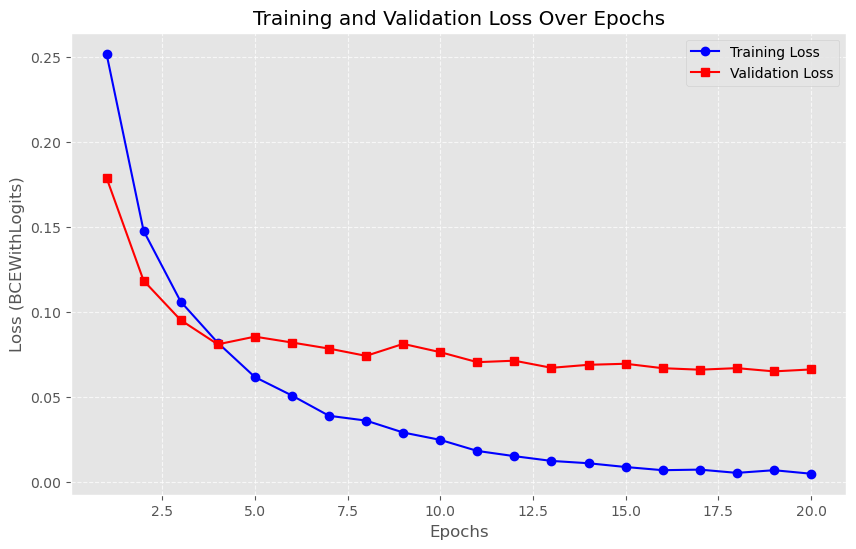

Loss Curve সফলভাবে সেভ হয়েছে এখানে: ./Loss_Curve.png


In [12]:
# --- ৬. বেস্ট হাইপারপ্যারামিটার দিয়ে ফাইনাল ট্রেইনিং ---
best_params = study.best_params
best_lr = best_params['lr']
best_optimizer_name = best_params['optimizer']
best_batch_size = best_params['batch_size']

print(f"\nফাইনাল মডেল ট্রেইন করা হচ্ছে: LR={best_lr:.6f}, Opt={best_optimizer_name}, Batch={best_batch_size}")

train_dataset = MultiLabelKeratitisDataset(X_train, y_train, IMG_DIR, transform=train_transforms)
val_dataset = MultiLabelKeratitisDataset(X_val, y_val, IMG_DIR, transform=val_test_transforms)
test_dataset = MultiLabelKeratitisDataset(X_test, y_test, IMG_DIR, transform=val_test_transforms)

# num_workers=0 করা হয়েছে
train_loader = DataLoader(train_dataset, batch_size=best_batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=best_batch_size, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=best_batch_size, shuffle=False, num_workers=0, pin_memory=True)

final_model = build_model(len(classes))
criterion = nn.BCEWithLogitsLoss()

if best_optimizer_name == "Adam":
    optimizer = optim.Adam(final_model.parameters(), lr=best_lr)
elif best_optimizer_name == "AdamW":
    optimizer = optim.AdamW(final_model.parameters(), lr=best_lr)
else:
    optimizer = optim.RMSprop(final_model.parameters(), lr=best_lr)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

FINAL_EPOCHS = 20
best_model_wts = copy.deepcopy(final_model.state_dict())
best_val_loss = float('inf')

train_losses = []
val_losses = []

for epoch in range(FINAL_EPOCHS):
    final_model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    train_loss = running_loss / len(train_dataset)
    scheduler.step()

    final_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = final_model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)

    val_loss = val_loss / len(val_dataset)
    
    # --- Memory Clearing ---
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache() 

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f'Epoch {epoch+1}/{FINAL_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_wts = copy.deepcopy(final_model.state_dict())

plt.figure(figsize=(10, 6))
plt.plot(range(1, FINAL_EPOCHS + 1), train_losses, label='Training Loss', color='blue', marker='o')
plt.plot(range(1, FINAL_EPOCHS + 1), val_losses, label='Validation Loss', color='red', marker='s')

plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (BCEWithLogits)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

loss_curve_path = './Loss_Curve.png'
plt.savefig(loss_curve_path, dpi=300, bbox_inches='tight')
plt.show() 
print(f"Loss Curve সফলভাবে সেভ হয়েছে এখানে: {loss_curve_path}")

In [20]:
import torch
from sklearn.metrics import accuracy_score
import gc

# --- ৭. ফাইনাল মডেল ইভাল্যুয়েশন এবং অ্যাকুরেসি ---
def evaluate_and_show_accuracy(model, data_loader, device, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []

    print("টেস্ট ডেটাসেটে ফাইনাল অ্যাকুরেসি ক্যালকুলেট করা হচ্ছে...\n")

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            # মডেল আউটপুট (Logits)
            outputs = model(inputs)

            # Sigmoid প্রয়োগ করে প্রোবাবিলিটি বের করা এবং থ্রেশহোল্ড সেট করা
            preds = torch.sigmoid(outputs) > threshold

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
            
            # --- Memory Clearing ---
            del inputs, labels, outputs, preds

    # লিস্ট থেকে টেন্সরে রূপান্তর
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    # ১. Element-wise Accuracy (Hamming Accuracy)
    element_acc = (all_preds == all_labels).mean()

    # ২. Exact Match Accuracy (Subset Accuracy)
    exact_match = accuracy_score(all_labels, all_preds)

    print("="*35)
    print("       FINAL ACCURACY REPORT")
    print("="*35)
    print(f"Element-wise Accuracy : {element_acc * 100:.2f}%")
    print(f"Exact Match Ratio     : {exact_match * 100:.2f}%")
    print("="*35)
    
    # শেষে মেমোরি ক্লিয়ার করা
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

    return element_acc, exact_match

# সেরা ওয়েট লোড করা (আপনার ট্রেইনিং থেকে পাওয়া best_model_wts)
final_model.load_state_dict(best_model_wts)

# টেস্ট ডেটাসেটের ওপর অ্যাকুরেসি চেক করা
test_element_acc, test_exact_acc = evaluate_and_show_accuracy(final_model, test_loader, device)

টেস্ট ডেটাসেটে ফাইনাল অ্যাকুরেসি ক্যালকুলেট করা হচ্ছে...



/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


       FINAL ACCURACY REPORT
Element-wise Accuracy : 98.35%
Exact Match Ratio     : 83.97%


In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import gc
from sklearn.metrics import accuracy_score, f1_score
from torchvision import models
import copy
import time

# --- ১. ডাইনামিক মডেল বিল্ডার ---
def build_dynamic_model(model_name, num_classes, device):
    if model_name == "ResNet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
        
    elif model_name == "DenseNet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        num_ftrs = model.classifier.in_features
        model.classifier = nn.Linear(num_ftrs, num_classes)
        
    return model.to(device)

# --- ২. ইভাল্যুয়েশন ফাংশন (F1-Score সহ) ---
def evaluate_model(model, data_loader, device, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = torch.sigmoid(outputs) > threshold
            
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
            
            del inputs, labels, outputs, preds

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    element_acc = (all_preds == all_labels).mean()
    exact_match = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return element_acc, exact_match, macro_f1

# --- ৩. রেজাল্ট লিস্ট তৈরি এবং আগের EfficientNet যোগ করা ---
results = []

print("আগের ট্রেইন করা EfficientNetV2_M ইভালুয়েট করা হচ্ছে...")
# final_model এবং best_model_wts আগের সেল থেকে অটোমেটিক পেয়ে যাবে
final_model.load_state_dict(best_model_wts)
eff_element_acc, eff_exact_match, eff_macro_f1 = evaluate_model(final_model, test_loader, device)

results.append({
    "Model Name": "EfficientNetV2_M (Optimized)",
    "Best Val Loss": "N/A (Already Trained)",
    "Element-wise Acc (%)": round(eff_element_acc * 100, 2),
    "Exact Match Acc (%)": round(eff_exact_match * 100, 2),
    "Macro F1-Score (%)": round(eff_macro_f1 * 100, 2),
    "Training Time (s)": "0.0"
})
print("✅ EfficientNetV2_M টেবিলে যুক্ত হয়েছে!\n")

# --- ৪. শুধু নতুন মডেলগুলোর জন্য ট্রেইনিং লুপ ---
# ট্রেইনিং লিস্ট থেকে EfficientNet বাদ!
model_names_to_train = ["ResNet50", "DenseNet121"]
      
FINAL_EPOCHS = 10     

for model_name in model_names_to_train:
    print(f"\n{'='*40}")
    print(f"🚀 Training Started for: {model_name}")
    print(f"{'='*40}")
    
    model = build_dynamic_model(model_name, len(classes), device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=best_lr)
    
    best_val_loss = float('inf')
    best_model_wts_current = copy.deepcopy(model.state_dict())
    
    start_time = time.time()
    
    for epoch in range(FINAL_EPOCHS):
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader: 
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            
            del inputs, labels, outputs, loss
            
        train_loss = running_loss / len(train_loader.dataset)
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                
                del inputs, labels, outputs, loss
                
        val_loss = val_loss / len(val_loader.dataset)
        
        gc.collect()
        if torch.backends.mps.is_available():
            torch.mps.empty_cache()
            
        print(f"Epoch {epoch+1}/{FINAL_EPOCHS} | Val Loss: {val_loss:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts_current = copy.deepcopy(model.state_dict())

    time_elapsed = time.time() - start_time
    
    print(f"\nEvaluating {model_name} on Test Data...")
    model.load_state_dict(best_model_wts_current)
    element_acc, exact_match, macro_f1 = evaluate_model(model, test_loader, device)
    
    results.append({
        "Model Name": model_name,
        "Best Val Loss": round(best_val_loss, 4),
        "Element-wise Acc (%)": round(element_acc * 100, 2),
        "Exact Match Acc (%)": round(exact_match * 100, 2),
        "Macro F1-Score (%)": round(macro_f1 * 100, 2),
        "Training Time (s)": round(time_elapsed, 2)
    })
    
    del model, optimizer, criterion
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    print(f"✅ {model_name} Training Completed and Memory Cleared.\n")

# --- ৫. রেজাল্ট কম্পারিজন এবং সেভ ---
results_df = pd.DataFrame(results)

print("\n" + "="*70)
print("🏆 FINAL MODEL COMPARISON REPORT 🏆")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)

csv_path = './model_comparison_results.csv'
results_df.to_csv(csv_path, index=False)
print(f"\n[Info] Comparison results saved to {csv_path} for future visualization!")

আগের ট্রেইন করা EfficientNetV2_M ইভালুয়েট করা হচ্ছে...


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


✅ EfficientNetV2_M টেবিলে যুক্ত হয়েছে!


🚀 Training Started for: ResNet50


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10 | Val Loss: 0.2380
Epoch 2/10 | Val Loss: 0.1751
Epoch 3/10 | Val Loss: 0.1445
Epoch 4/10 | Val Loss: 0.1984
Epoch 5/10 | Val Loss: 0.1323
Epoch 6/10 | Val Loss: 0.1246
Epoch 7/10 | Val Loss: 0.1357
Epoch 8/10 | Val Loss: 0.1282
Epoch 9/10 | Val Loss: 0.1424
Epoch 10/10 | Val Loss: 0.1158

Evaluating ResNet50 on Test Data...
✅ ResNet50 Training Completed and Memory Cleared.


🚀 Training Started for: DenseNet121


/opt/anaconda3/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/10 | Val Loss: 0.2077
Epoch 2/10 | Val Loss: 0.1986
Epoch 3/10 | Val Loss: 0.1818
Epoch 4/10 | Val Loss: 0.1915
Epoch 5/10 | Val Loss: 0.1533
Epoch 6/10 | Val Loss: 0.1791
Epoch 7/10 | Val Loss: 0.1298
Epoch 8/10 | Val Loss: 0.1363
Epoch 9/10 | Val Loss: 0.1198
Epoch 10/10 | Val Loss: 0.1276

Evaluating DenseNet121 on Test Data...
✅ DenseNet121 Training Completed and Memory Cleared.


🏆 FINAL MODEL COMPARISON REPORT 🏆
                  Model Name         Best Val Loss  Element-wise Acc (%)  Exact Match Acc (%)  Macro F1-Score (%) Training Time (s)
EfficientNetV2_M (Optimized) N/A (Already Trained)                 95.40                56.23               51.30               0.0
                    ResNet50                0.1158                 95.86                57.25               61.56           1792.26
                 DenseNet121                0.1198                 95.34                54.96               60.48            9934.1

[Info] Comparison results saved to ./mode